# BayesNF — baseline (VI + MAP)

Baseline BayesNF on ReKIS data. Two parallel fits: **VI**
(`BayesianNeuralFieldVI`) and **MAP** (`BayesianNeuralFieldMAP`). Same feature
set and default seasonality; hyperparameters are set inline below.

After each `train_eval_*` call the artefacts are uploaded to S3 under a folder
named by `name=...`:

```
s3://thesis-data-ismaktam/bayesnf/runs/<name>/
  config.json   metrics.json   preds.parquet   losses.npy   model.pkl
```

Re-running with the same `name` overwrites the folder.

Metrics are split into `dry / wet / wet-detector` slices with thresholds
`observed ≥ 0.5 mm` and `predicted ≥ 0.4 mm`. Calibration, spread–skill and the
semivariogram diagnostic are computed on the **wet-only** subset, because the
global view is dominated by zeros.

## 1. Environment and imports

In [2]:
import os
# JAX env vars must be set BEFORE the first `import jax`
os.environ.setdefault('JAX_LOG_COMPILES', '0')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.90')

import sys
import gc
import time
import json
import pickle
import threading
from pathlib import Path

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import bayesnf
from bayesnf.spatiotemporal import (
    BayesianNeuralFieldVI,
    BayesianNeuralFieldMAP,
)

jax.config.update('jax_default_matmul_precision', 'tensorfloat32')

# Repo root: notebooks/05_bayesnf/baseline/<this>.ipynb -> ../../..
ROOT = Path('../../..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

print(f'cwd      : {os.getcwd()}')
print(f'bayesnf  : {getattr(bayesnf, "__version__", "n/a")}')

cwd      : /root/precip_interpolation_thesis
bayesnf  : 0.1.3


## 2. GPU diagnostics

In [3]:
import subprocess

backend = jax.default_backend()
devices = jax.devices()
print(f'JAX backend : {backend}')
print(f'JAX devices : {devices}')
print(f'n local     : {jax.local_device_count()}')

if backend != 'gpu':
    print('\nJAX on CPU — this notebook expects a GPU.')

try:
    smi = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.used,memory.total',
         '--format=csv,noheader'],
        capture_output=True, text=True, timeout=5,
    )
    print('\nnvidia-smi:')
    print(smi.stdout)
except Exception as e:
    print(f'nvidia-smi unavailable: {e}')

JAX backend : gpu
JAX devices : [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]
n local     : 4

nvidia-smi:
NVIDIA A100-PCIE-40GB, 425 MiB, 40960 MiB
NVIDIA A100-PCIE-40GB, 425 MiB, 40960 MiB
NVIDIA A100-PCIE-40GB, 425 MiB, 40960 MiB
NVIDIA A100-PCIE-40GB, 425 MiB, 40960 MiB



## 3. Data and target config

Likelihood / target / data window. Model hyperparameters are set in the
train_eval cells below.

In [4]:
# --- Likelihood and target ---
LIKELIHOOD    = 'ZINB'
TARGET_COL    = 'rainfall_int'
NEEDS_RESCALE = True
PRECIP_SCALE  = 10

# --- Data window ---
FOLD       = 0
YEAR_START = 2013
YEAR_END   = 2022

# --- Output ---
LOCAL_RUNS = Path('results/bayesnf/runs')
LOCAL_RUNS.mkdir(parents=True, exist_ok=True)

# --- S3 ---
S3_BUCKET    = 'thesis-data-ismaktam'
S3_RUNS_ROOT = 'bayesnf/runs'

print(f'likelihood   : {LIKELIHOOD}  (target={TARGET_COL}, rescale={NEEDS_RESCALE})')
print(f'years        : {YEAR_START}-{YEAR_END}, fold {FOLD}')
print(f'local runs   : {LOCAL_RUNS}')
print(f's3 prefix    : s3://{S3_BUCKET}/{S3_RUNS_ROOT}/<name>/')

likelihood   : ZINB  (target=rainfall_int, rescale=True)
years        : 2013-2022, fold 0
local runs   : results/bayesnf/runs
s3 prefix    : s3://thesis-data-ismaktam/bayesnf/runs/<name>/


## 4. Load data from S3

Features (including FFRK: `idw, gos, svd_00..04`) are pre-computed and stored at
`s3://thesis-data-ismaktam/bayesnf/data/`. We load all potentially useful
columns; the actual subset is selected via `feature_cols` in train_eval.

In [5]:
DATA_S3_DIR = 'bayesnf/data'
DATA_DIR    = Path('results/bayesnf/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / f'bayesnf_fold{FOLD}_train.parquet'
test_path  = DATA_DIR / f'bayesnf_fold{FOLD}_test.parquet'

def _ensure_local(local_path: Path, s3_key: str) -> None:
    if local_path.exists():
        print(f'  cache hit: {local_path.name} ({local_path.stat().st_size/1e6:.0f} MB)')
        return
    import boto3
    print(f'  downloading s3://{S3_BUCKET}/{s3_key} ...')
    boto3.client('s3').download_file(S3_BUCKET, s3_key, str(local_path))
    print(f'  ↓ {local_path.name} ({local_path.stat().st_size/1e6:.0f} MB)')

_ensure_local(train_path, f'{DATA_S3_DIR}/bayesnf_fold{FOLD}_train.parquet')
_ensure_local(test_path,  f'{DATA_S3_DIR}/bayesnf_fold{FOLD}_test.parquet')

date_filter = [
    ('datetime', '>=', pd.Timestamp(f'{YEAR_START}-01-01')),
    ('datetime', '<=', pd.Timestamp(f'{YEAR_END}-12-31')),
]

ALL_GEO_COLS = [
    'datetime', 'latitude', 'longitude', 'x_proj', 'y_proj', 'elevation_m',
    'idw', 'gos',
    'svd_00', 'svd_01', 'svd_02', 'svd_03', 'svd_04',
    'bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa',
]
KEEP_COLS = ALL_GEO_COLS + ['rainfall', 'rainfall_int', 'station_id']

df_train = pd.read_parquet(train_path, filters=date_filter)[KEEP_COLS].copy()
df_test  = pd.read_parquet(test_path,  filters=date_filter)[KEEP_COLS].copy()
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_test ['datetime'] = pd.to_datetime(df_test ['datetime'])

assert df_train[ALL_GEO_COLS].isna().sum().sum() == 0, 'NaN in geo cols'
assert df_test [ALL_GEO_COLS].isna().sum().sum() == 0
assert 'rainfall_int' in df_train.columns, 'ZINB needs rainfall_int = round(10·mm)'

print(f'train rows / stations : {len(df_train):>10,} / {df_train["station_id"].nunique()}')
print(f'test  rows / stations : {len(df_test):>10,} / {df_test ["station_id"].nunique()}')
print(f'dates                 : {df_train["datetime"].min().date()} → {df_train["datetime"].max().date()}')
print(f'rainfall (mm) range   : [{df_train["rainfall"].min():.2f}, {df_train["rainfall"].max():.2f}]')
print(f'%zero (rainfall_int)  : {100*(df_train["rainfall_int"]==0).mean():.1f}%')
df_train.head()


  cache hit: bayesnf_fold0_train.parquet (1320 MB)
  cache hit: bayesnf_fold0_test.parquet (277 MB)
train rows / stations :  5,740,944 / 1572
test  rows / stations :  1,438,888 / 394
dates                 : 2013-01-01 → 2022-12-31
rainfall (mm) range   : [0.00, 206.80]
%zero (rainfall_int)  : 52.8%


,datetime,latitude,longitude,x_proj,y_proj,elevation_m,idw,gos,svd_00,svd_01,...,svd_04,bulk_density,clay,sand,silt,soc,water_10kpa,rainfall,rainfall_int,station_id
0,2013-01-01,50.750000,15.550000,4.712268e+06,3.085775e+06,1410.0,1.192109,1.038665,0.0,0.0,...,0.28,105.607903,201.660599,367.390106,430.932465,526.377625,440.415588,2.5,25,CZ_H1VITK01
1,2013-01-01,50.137135,15.462251,4.711127e+06,3.017297e+06,213.0,0.060510,0.069650,0.0,0.0,...,0.00,125.099129,306.760834,243.486084,353.339539,225.015762,-721.471436,0.0,0,CZ_H3CHLM01
2,2013-01-01,50.248100,15.198100,4.691434e+06,3.028242e+06,208.0,0.083411,0.046675,0.0,0.0,...,0.00,117.473495,337.345032,172.872147,360.899719,195.627258,-1072.900635,0.1,1,CZ_H3DYMO01
3,2013-01-01,50.433300,15.366700,4.701932e+06,3.049661e+06,301.0,0.320340,0.314733,0.0,0.0,...,0.00,39.006870,77.082283,69.430191,146.449249,74.091118,-7600.684082,0.6,6,CZ_H3JICI01
4,2013-01-01,50.370822,15.214447,4.691636e+06,3.041946e+06,225.0,0.147185,0.077029,0.0,0.0,...,0.00,122.927307,286.541656,115.863037,514.331177,176.030960,-557.900818,0.0,0,CZ_H3LIBA01


## 5. JIT-cache patch for `predict`

Same patch as in time_seasonality / geo_features. Without it `predict_bnf`
recompiles the closure on every chunk.

In [6]:
import bayesnf.inference as bnf_inference
import bayesnf.models as bnf_models
import bayesnf.spatiotemporal as bnf_st
from tensorflow_probability.substrates import jax as _tfp_jax

_tfd = _tfp_jax.distributions
_LD  = bnf_models.LikelihoodDist

# --- bounded likelihood (anti-blowup for NB / ZINB) ---------------------------
# NB/ZINB parametrisation in bayesnf: mean = softplus(MLP(x)), shape = softplus(p1).
# MLP output is unbounded above -> on test rows with extreme features `mean`
# can blow up to ~10^6 mm. Guard: a soft tanh wrapper around the raw params.
#
#  raw_pred  -> PRED_CAP * tanh(raw_pred / PRED_CAP)   (soft clip; if
#               |raw_pred| << PRED_CAP it does not affect training).
#  params[1] -> SHAPE_CAP * tanh(params[1] / SHAPE_CAP) -> shape in ~[2.5e-3, 6]
#               -> total_count = 1/shape in ~[0.17, 400].
#
# Target range for mean in rainfall_int units: <= 10 * 200 mm = 2000.
# PRED_CAP = 4000 (2x margin) -> softplus(+-4000) ~ {~0, 4000}.
PRED_CAP  = 4000.0
SHAPE_CAP = 6.0

_orig_make_likelihood = bnf_models.make_likelihood_model


def make_likelihood_bounded(params, x, mlp, mlp_template, distribution):
    if _LD(distribution) == _LD.NORMAL:
        return _orig_make_likelihood(params, x, mlp, mlp_template, distribution)

    treedef    = jax.tree_util.tree_structure(mlp_template)
    mlp_params = jax.tree_util.tree_unflatten(treedef, params[3:])
    raw_pred   = mlp.apply(mlp_params, x)
    bounded_pred = PRED_CAP * jnp.tanh(raw_pred / PRED_CAP)
    mean       = jax.nn.softplus(bounded_pred)

    bounded_p1 = SHAPE_CAP * jnp.tanh(params[1] / SHAPE_CAP)
    shape      = jax.nn.softplus(bounded_p1)
    logits     = -jnp.log(shape) - jnp.log(mean)

    if _LD(distribution) == _LD.NB:
        return _tfd.Independent(
            _tfd.NegativeBinomial(total_count=1.0 / shape, logits=logits), 1)
    elif _LD(distribution) == _LD.ZINB:
        inflated_loc_probs = 1.0 / (1.0 + jnp.exp(-params[2]))
        return _tfd.Independent(
            _tfd.ZeroInflatedNegativeBinomial(
                total_count=1.0 / shape, logits=logits,
                inflated_loc_probs=inflated_loc_probs * jnp.ones(shape=mean.shape)), 1)
    raise AssertionError(f'unknown distribution: {distribution}')


bnf_models.make_likelihood_model = make_likelihood_bounded
print(f'bounded likelihood: mean <= ~{PRED_CAP:.0f} (rainfall_int units = '
      f'{PRED_CAP/PRECIP_SCALE:.0f} mm/day),  total_count in [{1/jax.nn.softplus(SHAPE_CAP):.3f}, '
      f'{1/jax.nn.softplus(-SHAPE_CAP):.1f}]')


# --- predict JIT-cache (same as in time_seasonality / geo_features) ----------
def _patched_predict(self, table, quantiles=(0.5,), approximate_quantiles=False):
    test_data = self.data_handler.get_test(table)
    distribution = bnf_models.LikelihoodDist(self.observation_model)

    if getattr(self, '_cached_forecast_inner', None) is None:
        model_args = self._model_args(test_data.shape)
        fn = bnf_inference._make_forecast_inner(model_args, distribution)
        for _ in range(self._ensemble_dims - 1):
            fn = jax.vmap(fn, in_axes=(0, None))
        fn = jax.pmap(fn, in_axes=(0, None))
        self._cached_forecast_inner = fn

    forecast_inner = self._cached_forecast_inner
    axis = tuple(range(self._ensemble_dims))

    forecast_params = bnf_inference.forecast_parameters_batched(
        test_data, self.params_, distribution, forecast_inner,
    )

    if distribution == bnf_models.LikelihoodDist.NORMAL:
        means, scales = forecast_params
        forecast_means = means
        forecast_quantiles = bnf_inference._get_percentile_normal(
            forecast_means, scales, quantiles, axis=axis,
            approximate=approximate_quantiles,
        )
    elif distribution in (bnf_models.LikelihoodDist.NB, bnf_models.LikelihoodDist.ZINB):
        obs_d = bnf_inference._build_observation_distribution(distribution, forecast_params)
        forecast_means = obs_d.mean()
        forecast_quantiles = jax.vmap(
            lambda q: bnf_inference._get_nb_quantiles_root(obs_d, q, ensemble_axes=axis)
        )(jnp.array(quantiles))
    else:
        raise ValueError(f'Unknown distribution: {distribution}')

    return forecast_means, forecast_quantiles


bnf_st.BayesianNeuralFieldEstimator.predict = _patched_predict
print('patched BayesianNeuralFieldEstimator.predict')

✓ bounded likelihood: mean ≤ ~4000 (rainfall_int units = 400 mm/day),  total_count ∈ [0.167, 403.9]
✓ patched BayesianNeuralFieldEstimator.predict


## 6. Helpers: metrics, save, S3 upload, train_eval_vi / train_eval_map

One large block. Run once; the training cells below just call
`train_eval_vi(name=..., **overrides)` or `train_eval_map(...)`.

**Metric groups.**

| Group | Slice | Metrics |
|-------|-------|---------|
| Global | full test | RMSE, MAE, bias, CRPS, cov90, cov80 |
| Wet    | `y ≥ 0.5 mm` | RMSE_wet, MAE_wet, CRPS_wet, cov90_wet, cov80_wet |
| Dry    | `y < 0.5 mm` | MAE_dry, RMSE_dry, bias_dry |
| Detector | wet classifier with `predicted ≥ 0.4 mm`, observed `≥ 0.5 mm` | TP/FP/TN/FN, accuracy, precision, recall, F1, Brier |

In [7]:
from properscoring import crps_ensemble
import boto3

# --- thresholds ---
WET_THRESHOLD_MM   = 0.5   # y_true wet  <=>  y >= 0.5 mm
PRED_DRY_THRESHOLD = 0.4   # model "predicted dry"  <=>  mean_mm < 0.4

# --- quantiles ---
QUANTILES = (0.05, 0.1, 0.2, 0.3, 0.4, 0.50, 0.6, 0.7, 0.8, 0.9, 0.95)
QUANTILE_LABELS = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
Q05_I = QUANTILE_LABELS.index(5)
Q10_I = QUANTILE_LABELS.index(10)
Q50_I = QUANTILE_LABELS.index(50)
Q90_I = QUANTILE_LABELS.index(90)
Q95_I = QUANTILE_LABELS.index(95)

PRED_CHUNK = 500_000

# --- defaults (geo features + seasonality) ---
GEO_DEFAULTS = dict(
    feature_cols=['datetime', 'latitude', 'longitude', 'elevation_m',
                  'idw', 'gos',
                  'svd_00', 'svd_01', 'svd_02', 'svd_03', 'svd_04',
                  'bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa'],
    interactions=[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
                  (1, 2), (1, 3), (2, 3)],
)
SEAS_DEFAULT = dict(periods=['W', 'Y'], harmonics=[1, 10])


# ----------------------------------------------------------------------
def _metrics(y_true, mean_mm, q_arr):
    """Returns dict with global / wet / dry / detector groups."""
    lo90 = q_arr[:, Q05_I]; hi90 = q_arr[:, Q95_I]
    lo80 = q_arr[:, Q10_I]; hi80 = q_arr[:, Q90_I]

    obs_wet  = y_true  >= WET_THRESHOLD_MM
    pred_wet = mean_mm >= PRED_DRY_THRESHOLD
    tp = int(( obs_wet &  pred_wet).sum())
    tn = int((~obs_wet & ~pred_wet).sum())
    fp = int((~obs_wet &  pred_wet).sum())
    fn = int(( obs_wet & ~pred_wet).sum())
    n  = len(y_true)
    eps = 1e-12

    accuracy  = (tp + tn) / max(n, 1)
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = 2 * precision * recall / max(precision + recall, eps)
    brier     = float(np.mean((pred_wet.astype(np.float32) - obs_wet.astype(np.float32))**2))

    out = {
        # global
        'rmse'    : float(np.sqrt(np.mean((mean_mm - y_true) ** 2))),
        'mae'     : float(np.mean(np.abs(mean_mm - y_true))),
        'bias'    : float(np.mean(mean_mm - y_true)),
        'crps'    : float(crps_ensemble(y_true, q_arr).mean()),
        'cov90'   : float(np.mean((y_true >= lo90) & (y_true <= hi90))),
        'cov80'   : float(np.mean((y_true >= lo80) & (y_true <= hi80))),
        'n_total' : int(n),

        # detector
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'accuracy' : float(accuracy),
        'precision': float(precision),
        'recall'   : float(recall),
        'f1'       : float(f1),
        'brier'    : brier,
    }

    # wet slice
    if obs_wet.sum() > 0:
        out.update({
            'rmse_wet'  : float(np.sqrt(np.mean((mean_mm[obs_wet] - y_true[obs_wet]) ** 2))),
            'mae_wet'   : float(np.mean(np.abs(mean_mm[obs_wet] - y_true[obs_wet]))),
            'crps_wet'  : float(crps_ensemble(y_true[obs_wet], q_arr[obs_wet]).mean()),
            'cov90_wet' : float(np.mean((y_true[obs_wet] >= lo90[obs_wet]) & (y_true[obs_wet] <= hi90[obs_wet]))),
            'cov80_wet' : float(np.mean((y_true[obs_wet] >= lo80[obs_wet]) & (y_true[obs_wet] <= hi80[obs_wet]))),
            'n_wet'     : int(obs_wet.sum()),
        })
    else:
        out.update({k: float('nan') for k in
                    ('rmse_wet','mae_wet','crps_wet','cov90_wet','cov80_wet')})
        out['n_wet'] = 0

    # dry slice
    if (~obs_wet).sum() > 0:
        d = ~obs_wet
        out.update({
            'mae_dry'  : float(np.mean(np.abs(mean_mm[d] - y_true[d]))),
            'rmse_dry' : float(np.sqrt(np.mean((mean_mm[d] - y_true[d]) ** 2))),
            'bias_dry' : float(np.mean(mean_mm[d] - y_true[d])),
            'n_dry'    : int(d.sum()),
        })
    else:
        out.update({'mae_dry': float('nan'), 'rmse_dry': float('nan'),
                    'bias_dry': float('nan'), 'n_dry': 0})
    return out


def _save_run(run_name: str, model, losses, preds_df, metrics, config):
    """Persist all artifacts under LOCAL_RUNS/<run_name>/.

    Known TFP issue: `model.params_` is a `structural_tuple.StructTuple`, whose
    class is created dynamically inside a function (`weakref` cache), so
    `pickle` cannot resolve it by qualified name on load. We unpack it into a
    dict with explicit field names and save plain numpy leaves.
    """
    sub_dir = LOCAL_RUNS / run_name
    sub_dir.mkdir(parents=True, exist_ok=True)

    np.save(sub_dir / 'losses.npy', np.asarray(losses))
    with open(sub_dir / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)
    with open(sub_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)
    preds_df.to_parquet(sub_dir / 'preds.parquet', index=False)

    # Flatten StructTuple -> dict.
    p = model.params_
    params_dict = {name: np.asarray(val) for name, val in zip(p._fields, p)}

    # All ctor args, so the model can be rebuilt on load.
    init_kwargs = {
        'width': model.width, 'depth': model.depth,
        'freq': model.freq, 'timetype': model.timetype,
        'seasonality_periods': list(model.seasonality_periods),
        'num_seasonal_harmonics': list(model.num_seasonal_harmonics),
        'feature_cols': list(model.feature_cols),
        'target_col':  model.target_col,
        'standardize': list(model.standardize),
        'observation_model': model.observation_model,
        'interactions': [list(t) for t in model.interactions]
                         if model.interactions is not None else None,
    }

    # data_handler scalers (mean / std for standardize) - needed at predict time.
    dh = model.data_handler
    standardize_ = {
        'mean': np.asarray(dh.standardize_['mean'])  if hasattr(dh, 'standardize_') and dh.standardize_ else None,
        'std' : np.asarray(dh.standardize_['std'])   if hasattr(dh, 'standardize_') and dh.standardize_ else None,
    }

    payload = {
        'params_dict' : params_dict,
        'param_fields': list(p._fields),
        'init_kwargs' : init_kwargs,
        'standardize_': standardize_,
        'inference'   : config.get('inference'),
    }
    with open(sub_dir / 'model.pkl', 'wb') as f:
        pickle.dump(payload, f)
    print(f'  saved {len(params_dict)} param fields + meta to {sub_dir / "model.pkl"}')
    return sub_dir


def _load_run_model(run_name: str):
    """Inverse of _save_run: returns an estimator ready to predict.

    Not strictly needed in this baseline notebook (it reads preds.parquet
    directly), but useful for grid predictions later.
    """
    sub_dir = LOCAL_RUNS / run_name
    with open(sub_dir / 'model.pkl', 'rb') as f:
        payload = pickle.load(f)

    from tensorflow_probability.python.internal import structural_tuple
    inference = payload['inference']
    cls = bnf_st.BayesianNeuralFieldVI if inference == 'vi' else bnf_st.BayesianNeuralFieldMAP
    model = cls(**payload['init_kwargs'])

    # Rebuild StructTuple from dict
    StructT = structural_tuple.structtuple(payload['param_fields'])
    model.params_ = StructT(*(payload['params_dict'][k] for k in payload['param_fields']))

    # Restore scalers
    std = payload.get('standardize_') or {}
    if std.get('mean') is not None and std.get('std') is not None:
        model.data_handler.standardize_ = {
            'mean': std['mean'], 'std': std['std'],
        }
    return model


def _upload_run_s3(run_name: str) -> None:
    """Idempotently upload LOCAL_RUNS/<run_name>/ to s3://bucket/bayesnf/runs/<run_name>/."""
    src_dir = LOCAL_RUNS / run_name
    if not src_dir.exists():
        print(f'  {src_dir} does not exist, skip upload')
        return
    s3 = boto3.client('s3')
    for f in sorted(src_dir.iterdir()):
        if not f.is_file():
            continue
        key = f'{S3_RUNS_ROOT}/{run_name}/{f.name}'
        s3.upload_file(str(f), S3_BUCKET, key)
        size_mb = f.stat().st_size / 1e6
        print(f'  s3://{S3_BUCKET}/{key}  ({size_mb:.1f} MB)')


# ----------------------------------------------------------------------
def _build_predict_metrics(model, df_test_sub, name):
    """Run chunked predict, compute metrics, return (mean_per_point, q_arr, metrics_dict, preds_df)."""
    means_chunks, q_chunks = [], []
    t0 = time.time()
    n = len(df_test_sub)
    for i in range(0, n, PRED_CHUNK):
        j = min(i + PRED_CHUNK, n)
        m, q = model.predict(df_test_sub.iloc[i:j], quantiles=QUANTILES, approximate_quantiles=True)
        means_chunks.append(np.asarray(m))
        q_chunks.append(np.asarray(q))
    gc.collect()
    predict_time_s = time.time() - t0
    print(f'  predict {n:,} rows in {predict_time_s:.0f}s')

    means_raw = np.concatenate(means_chunks, axis=-1)
    q_raw     = np.concatenate(q_chunks, axis=-1)
    mean_per_point = means_raw.reshape(-1, n).mean(axis=0)
    q_flat = q_raw.reshape(q_raw.shape[0], -1, n).mean(axis=1)

    if NEEDS_RESCALE:
        mean_per_point = mean_per_point / PRECIP_SCALE
        q_flat = q_flat / PRECIP_SCALE

    # --- diagnostics + safety clip ---------------------------------------
    n_bad_mean = int((~np.isfinite(mean_per_point)).sum())
    n_bad_q    = int((~np.isfinite(q_flat)).sum())
    abs_mean   = np.abs(mean_per_point)
    pct = np.nanpercentile(abs_mean, [50, 95, 99, 99.9])
    print(f'  diag |mean_mm|: p50={pct[0]:.2f}  p95={pct[1]:.2f}  '
          f'p99={pct[2]:.2f}  p99.9={pct[3]:.2f}  max={np.nanmax(abs_mean):.2f}')
    print(f'  diag non-finite: mean={n_bad_mean} ({n_bad_mean/n*100:.3f}%) '
          f'q={n_bad_q} ({n_bad_q/q_flat.size*100:.3f}%)')

    # Safety-net clip: 250 mm/day is the absolute max on station data
    # (world daily record ~ 1825 mm is exceedingly rare; in Germany realistic
    # values are <= 200 mm). We clip the mean more aggressively than quantiles
    # so we do not destroy calibration.
    HARD_CAP_MEAN_MM = 250.0
    HARD_CAP_Q_MM    = 500.0
    n_clip_mean = int((mean_per_point > HARD_CAP_MEAN_MM).sum())
    n_clip_q    = int((q_flat > HARD_CAP_Q_MM).sum())
    if n_clip_mean or n_clip_q:
        print(f'  clipping: mean>{HARD_CAP_MEAN_MM}mm n={n_clip_mean}, '
              f'q>{HARD_CAP_Q_MM}mm n={n_clip_q}')
    mean_per_point = np.clip(np.nan_to_num(mean_per_point, nan=0.0,
                                           posinf=HARD_CAP_MEAN_MM, neginf=0.0),
                             0.0, HARD_CAP_MEAN_MM)
    q_flat = np.clip(np.nan_to_num(q_flat, nan=0.0,
                                    posinf=HARD_CAP_Q_MM, neginf=0.0),
                     0.0, HARD_CAP_Q_MM)

    y_true = df_test_sub['rainfall'].to_numpy()
    q_arr = np.stack(list(q_flat), axis=1)
    q_arr = np.sort(q_arr, axis=1)

    metrics = _metrics(y_true, mean_per_point, q_arr)
    metrics.update({
        'name': name, 'n_quantiles': len(QUANTILES),
        'predict_time_s': float(predict_time_s),
        'n_nonfinite_mean': n_bad_mean,
        'n_nonfinite_q'   : n_bad_q,
        'n_clipped_mean'  : n_clip_mean,
        'n_clipped_q'     : n_clip_q,
        'p99_abs_mean_mm' : float(pct[2]),
        'p999_abs_mean_mm': float(pct[3]),
    })

    preds_df = df_test_sub[['station_id', 'datetime']].copy()
    preds_df['observed_mm'] = y_true
    preds_df['mean_mm']     = mean_per_point
    for lbl, qv in zip(QUANTILE_LABELS, q_flat):
        preds_df[f'q{lbl:02d}'] = qv

    return mean_per_point, q_arr, metrics, preds_df


def _print_summary(metrics):
    m = metrics
    print(f'  CRPS     = {m["crps"]:.4f}    CRPS_wet = {m["crps_wet"]:.4f}')
    print(f'  MAE      = {m["mae"]:.4f}    MAE_wet  = {m["mae_wet"]:.4f}    MAE_dry  = {m["mae_dry"]:.4f}')
    print(f'  RMSE     = {m["rmse"]:.4f}   RMSE_wet = {m["rmse_wet"]:.4f}   RMSE_dry = {m["rmse_dry"]:.4f}')
    print(f'  bias     = {m["bias"]:+.4f}  cov90    = {m["cov90"]:.3f}      cov80    = {m["cov80"]:.3f}')
    print(f'  detector -> acc={m["accuracy"]:.3f}  P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}  Brier={m["brier"]:.4f}')
    print(f'              TP={m["tp"]:,}  FP={m["fp"]:,}  TN={m["tn"]:,}  FN={m["fn"]:,}')


def _heartbeat_start(name):
    stop = threading.Event()
    def _beat():
        t0 = time.time()
        while not stop.wait(20.0):
            print(f'    [{name}] still training ({time.time()-t0:.0f}s)', flush=True)
    thr = threading.Thread(target=_beat, daemon=True); thr.start()
    return stop, thr


# ----------------------------------------------------------------------
def train_eval_vi(
    name: str,
    *,
    num_epochs: int,
    batch_size: int,
    ensemble_size: int,
    learning_rate: float,
    kl_weight: float,
    sample_size_posterior: int,
    width: int = 256,
    depth: int = 2,
    seed: int = 0,
    seasonality_periods=None,
    num_seasonal_harmonics=None,
    feature_cols=None,
    interactions=None,
) -> dict:
    seasonality_periods    = seasonality_periods    or SEAS_DEFAULT['periods']
    num_seasonal_harmonics = num_seasonal_harmonics or SEAS_DEFAULT['harmonics']
    feature_cols           = feature_cols           or GEO_DEFAULTS['feature_cols']
    interactions           = interactions           or GEO_DEFAULTS['interactions']

    assert len(seasonality_periods) == len(num_seasonal_harmonics)
    assert feature_cols[0] == 'datetime'
    for i, j in interactions:
        assert 0 <= i < len(feature_cols) and 0 <= j < len(feature_cols)

    print(f'\n{"="*78}')
    print(f'  [VI] {name}')
    print(f'       seasonality={seasonality_periods}/{num_seasonal_harmonics}')
    print(f'       features ({len(feature_cols)}): {feature_cols}')
    print(f'       width={width} depth={depth}  epochs={num_epochs}  batch={batch_size}')
    print(f'       ensemble={ensemble_size}  lr={learning_rate}  kl={kl_weight}  sample_post={sample_size_posterior}')
    print(f'{"="*78}')

    standardize_cols = [c for c in feature_cols if c != 'datetime']
    model = BayesianNeuralFieldVI(
        width=width, depth=depth,
        freq='D', timetype='index',
        seasonality_periods=seasonality_periods,
        num_seasonal_harmonics=num_seasonal_harmonics,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        standardize=standardize_cols,
        observation_model=LIKELIHOOD,
        interactions=interactions,
    )

    keep = feature_cols + ['rainfall', 'rainfall_int', 'station_id']
    df_train_sub = df_train[keep]
    df_test_sub  = df_test [keep]

    stop, thr = _heartbeat_start(name)
    t0 = time.time()
    try:
        model = model.fit(
            df_train_sub,
            seed=jax.random.PRNGKey(seed),
            num_epochs=num_epochs,
            ensemble_size=ensemble_size,
            learning_rate=learning_rate,
            batch_size=batch_size,
            kl_weight=kl_weight,
            sample_size_posterior=sample_size_posterior,
        )
    finally:
        stop.set(); thr.join(timeout=1)
    fit_time_s = time.time() - t0
    print(f'  fit done in {fit_time_s:.0f}s ({fit_time_s/60:.1f} min)')

    losses_arr = np.asarray(model.losses_)
    _, _, metrics, preds_df = _build_predict_metrics(model, df_test_sub, name)
    metrics.update({
        'inference'             : 'vi',
        'seasonality_periods'   : seasonality_periods,
        'num_seasonal_harmonics': num_seasonal_harmonics,
        'feature_cols'          : feature_cols,
        'interactions'          : interactions,
        'n_features'            : len(feature_cols),
        'fit_time_s'            : float(fit_time_s),
    })

    config = {
        'inference': 'vi', 'name': name,
        'width': width, 'depth': depth,
        'num_epochs': num_epochs, 'batch_size': batch_size,
        'ensemble_size': ensemble_size, 'learning_rate': learning_rate,
        'kl_weight': kl_weight, 'sample_size_posterior': sample_size_posterior,
        'seed': seed,
        'seasonality_periods': seasonality_periods,
        'num_seasonal_harmonics': num_seasonal_harmonics,
        'feature_cols': feature_cols, 'interactions': interactions,
        'likelihood': LIKELIHOOD, 'target_col': TARGET_COL,
        'fold': FOLD, 'year_start': YEAR_START, 'year_end': YEAR_END,
    }
    _save_run(name, model, losses_arr, preds_df, metrics, config)
    _upload_run_s3(name)
    _print_summary(metrics)

    del model
    jax.clear_caches(); gc.collect()
    return metrics


def train_eval_map(
    name: str,
    *,
    num_epochs: int,
    batch_size: int,
    ensemble_size: int,
    learning_rate: float,
    num_splits: int = 1,
    width: int = 256,
    depth: int = 2,
    seed: int = 0,
    seasonality_periods=None,
    num_seasonal_harmonics=None,
    feature_cols=None,
    interactions=None,
) -> dict:
    seasonality_periods    = seasonality_periods    or SEAS_DEFAULT['periods']
    num_seasonal_harmonics = num_seasonal_harmonics or SEAS_DEFAULT['harmonics']
    feature_cols           = feature_cols           or GEO_DEFAULTS['feature_cols']
    interactions           = interactions           or GEO_DEFAULTS['interactions']

    assert len(seasonality_periods) == len(num_seasonal_harmonics)
    assert feature_cols[0] == 'datetime'

    print(f'\n{"="*78}')
    print(f'  [MAP] {name}')
    print(f'        seasonality={seasonality_periods}/{num_seasonal_harmonics}')
    print(f'        features ({len(feature_cols)}): {feature_cols}')
    print(f'        width={width} depth={depth}  epochs={num_epochs}  batch={batch_size}')
    print(f'        ensemble={ensemble_size}  lr={learning_rate}  splits={num_splits}')
    print(f'{"="*78}')

    standardize_cols = [c for c in feature_cols if c != 'datetime']
    model = BayesianNeuralFieldMAP(
        width=width, depth=depth,
        freq='D', timetype='index',
        seasonality_periods=seasonality_periods,
        num_seasonal_harmonics=num_seasonal_harmonics,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        standardize=standardize_cols,
        observation_model=LIKELIHOOD,
        interactions=interactions,
    )

    keep = feature_cols + ['rainfall', 'rainfall_int', 'station_id']
    df_train_sub = df_train[keep]
    df_test_sub  = df_test [keep]

    stop, thr = _heartbeat_start(name)
    t0 = time.time()
    try:
        model = model.fit(
            df_train_sub,
            seed=jax.random.PRNGKey(seed),
            num_epochs=num_epochs,
            ensemble_size=ensemble_size,
            learning_rate=learning_rate,
            batch_size=batch_size,
            num_splits=num_splits,
        )
    finally:
        stop.set(); thr.join(timeout=1)
    fit_time_s = time.time() - t0
    print(f'  fit done in {fit_time_s:.0f}s ({fit_time_s/60:.1f} min)')

    losses_arr = np.asarray(model.losses_)
    _, _, metrics, preds_df = _build_predict_metrics(model, df_test_sub, name)
    metrics.update({
        'inference'             : 'map',
        'seasonality_periods'   : seasonality_periods,
        'num_seasonal_harmonics': num_seasonal_harmonics,
        'feature_cols'          : feature_cols,
        'interactions'          : interactions,
        'n_features'            : len(feature_cols),
        'fit_time_s'            : float(fit_time_s),
    })

    config = {
        'inference': 'map', 'name': name,
        'width': width, 'depth': depth,
        'num_epochs': num_epochs, 'batch_size': batch_size,
        'ensemble_size': ensemble_size, 'learning_rate': learning_rate,
        'num_splits': num_splits, 'seed': seed,
        'seasonality_periods': seasonality_periods,
        'num_seasonal_harmonics': num_seasonal_harmonics,
        'feature_cols': feature_cols, 'interactions': interactions,
        'likelihood': LIKELIHOOD, 'target_col': TARGET_COL,
        'fold': FOLD, 'year_start': YEAR_START, 'year_end': YEAR_END,
    }
    _save_run(name, model, losses_arr, preds_df, metrics, config)
    _upload_run_s3(name)
    _print_summary(metrics)

    del model
    jax.clear_caches(); gc.collect()
    return metrics


print('helpers ready')
print('  GEO_DEFAULTS : n_features =', len(GEO_DEFAULTS['feature_cols']),
      ', n_interactions =', len(GEO_DEFAULTS['interactions']))
print('  SEAS_DEFAULT :', SEAS_DEFAULT)
print('  thresholds   : observed wet >=', WET_THRESHOLD_MM, 'mm,  predicted wet >=', PRED_DRY_THRESHOLD, 'mm')

✓ helpers ready
  GEO_DEFAULTS : n_features = 17 , n_interactions = 8
  SEAS_DEFAULT : {'periods': ['W', 'Y'], 'harmonics': [1, 10]}
  thresholds   : observed wet ≥ 0.5 mm,  predicted wet ≥ 0.4 mm


## 7. Train — VI

All hyperparameters are set here. Defaults below match a config that ran
successfully on 10 years of data (CRPS ~ 0.34 on the full test set).

In [8]:
m_vi = train_eval_vi(
    name='vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5',
    # core hyperparams
    num_epochs            = 100,
    batch_size            = 65256,
    ensemble_size         = 32,
    learning_rate         = 0.005,
    kl_weight             = 0.1,
    sample_size_posterior = 5,
    # architecture
    width = 256,
    depth = 2,
    seed  = 0,
    # seasonality / features / interactions: defaults from SEAS_DEFAULT / GEO_DEFAULTS
)


  [VI] vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5
       seasonality=['W', 'Y']/[1, 10]
       features (17): ['datetime', 'latitude', 'longitude', 'elevation_m', 'idw', 'gos', 'svd_00', 'svd_01', 'svd_02', 'svd_03', 'svd_04', 'bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']
       width=256 depth=2  epochs=100  batch=65256
       ensemble=32  lr=0.005  kl=0.1  sample_post=5
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (20s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (41s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (61s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (81s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (101s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (121s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (141s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training (161s)
    [vi__WY_h1_10__ffrk_full_32_5e-3_kl0.1_s5] still training 

## 8. Train — MAP

MAP inference does not use `kl_weight` / `sample_size_posterior` (see the
`BayesianNeuralFieldMAP.fit` signature). The library default `lr = 0.005` and
`epochs = 5000` apply, but MAP does **not** scale by `train_data.shape[0] //
batch_size`, so 5000 here is 5000 real steps on a full batch (or
`epochs * (n_train//batch)` if `batch_size` is set).

The defaults below are a sensible starting point; tune as needed.

In [ ]:
m_map = train_eval_map(
    name='map__WY_h1_10__ffrk_full_100_32_5e-3_s1',
    # core hyperparams
    num_epochs    = 100,
    batch_size    = 131072,
    ensemble_size = 32,
    learning_rate = 0.005,
    num_splits    = 1,
    # architecture
    width = 256,
    depth = 2,
    seed  = 0,
)



  [MAP] vi__WY_h1_10__ffrk_full_100_32_5e-3_s1
        seasonality=['W', 'Y']/[1, 10]
        features (17): ['datetime', 'latitude', 'longitude', 'elevation_m', 'idw', 'gos', 'svd_00', 'svd_01', 'svd_02', 'svd_03', 'svd_04', 'bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']
        width=256 depth=2  epochs=100  batch=131072
        ensemble=32  lr=0.005  splits=1


KeyboardInterrupt: 

## 9. Load artefacts for analysis

All cells below are self-contained — they read `results/bayesnf/runs/<EXP_NAME>/`.
By default we look at the VI run; switch `EXP_NAME` to `map__WY_h1_10__ffrk_full`
to inspect MAP.

In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXP_NAME = 'vi__WY_h1_10__ffrk_full'   # switch to 'map__...' to inspect the MAP run
EXP_DIR  = Path('results/bayesnf/runs') / EXP_NAME
assert EXP_DIR.exists(), f'experiment folder not found: {EXP_DIR}'

metrics = json.loads((EXP_DIR / 'metrics.json').read_text())
config  = json.loads((EXP_DIR / 'config.json' ).read_text())
losses  = np.load   (EXP_DIR / 'losses.npy')
# pmap shape: (n_devices, ens_per_device, n_steps[, ...]) -> collapse to (n_members, n_steps)
if losses.ndim > 2:
    losses = losses.reshape(-1, losses.shape[-1])
preds   = pd.read_parquet(EXP_DIR / 'preds.parquet')
preds['datetime'] = pd.to_datetime(preds['datetime'])

# station coords for spatial diagnostics
if 'df_test' not in globals():
    test_path = Path('results/bayesnf/data') / f'bayesnf_fold{config["fold"]}_test.parquet'
    df_test = pd.read_parquet(
        test_path,
        columns=['station_id','datetime','latitude','longitude','rainfall'],
        filters=[('datetime','>=', pd.Timestamp(f'{config["year_start"]}-01-01')),
                 ('datetime','<=', pd.Timestamp(f'{config["year_end"]}-12-31'))])
    df_test['datetime'] = pd.to_datetime(df_test['datetime'])

coords = (df_test[['station_id','latitude','longitude']]
            .drop_duplicates('station_id').set_index('station_id'))
preds = preds.merge(coords, left_on='station_id', right_index=True, how='left')

print(f'experiment        : {EXP_NAME}  (inference={config["inference"]})')
print(f'losses shape      : {losses.shape}  (ensemble x epochs)')
print(f'preds rows        : {len(preds):,}')
print(f'stations in test  : {preds["station_id"].nunique()}')
print(f'date range        : {preds["datetime"].min().date()} -> {preds["datetime"].max().date()}')

experiment        : vi__WY_h1_10__ffrk_full  (inference=vi)
losses shape      : (16, 4300)  (ensemble × epochs)
preds rows        : 1,438,888
stations in test  : 394
date range        : 2013-01-01 → 2022-12-31


## 10. Loss curves across the ensemble

Each blue line is one ensemble member. For VI it is the ELBO loss; for MAP it is
the negative log-posterior. Consistency across members suggests robustness; a
plateau suggests room for more epochs.

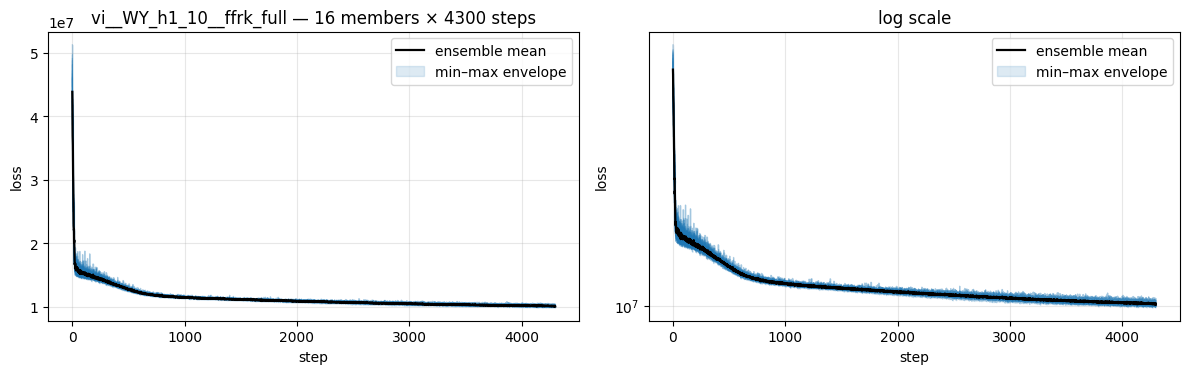

converged at step 3874/4299 (|loss - loss_final| <= 1%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mean_loss = losses.mean(0)
epochs = np.arange(losses.shape[1])
for ax, log in zip(axes, [False, True]):
    for m in range(losses.shape[0]):
        ax.plot(epochs, losses[m], color='tab:blue', alpha=0.3, lw=0.8)
    ax.plot(epochs, mean_loss, color='black', lw=1.6, label='ensemble mean')
    ax.fill_between(epochs, losses.min(0), losses.max(0),
                    color='tab:blue', alpha=0.15, label='min-max envelope')
    ax.set_xlabel('step'); ax.set_ylabel('loss')
    ax.grid(alpha=0.3); ax.legend()
    if log:
        ax.set_yscale('symlog'); ax.set_title('log scale')
    else:
        ax.set_title(f'{EXP_NAME} - {losses.shape[0]} members x {losses.shape[1]} steps')
plt.tight_layout(); plt.show()

final = mean_loss[-1]; tol = 0.01 * abs(final)
converged_at = next((e for e, v in enumerate(mean_loss) if abs(v - final) <= tol),
                    losses.shape[1] - 1)
print(f'converged at step {converged_at}/{losses.shape[1]-1} '
      f'(|loss - loss_final| <= 1%)')

## 11. Prediction metrics

Three blocks: **global** (full test), **wet-only** (observed ≥ 0.5 mm),
**dry-only** (observed < 0.5 mm). One extra block reports runtime.

In [13]:
def _fmt(k, v):
    if isinstance(v, float): return f'  {k:14s} = {v:>10.4f}'
    if isinstance(v, int):   return f'  {k:14s} = {v:>10,d}'
    return                          f'  {k:14s} = {v}'

ORDER_GLOBAL = ['rmse','mae','bias','crps','cov90','cov80','n_total','n_quantiles']
ORDER_WET    = ['rmse_wet','mae_wet','crps_wet','cov90_wet','cov80_wet','n_wet']
ORDER_DRY    = ['mae_dry','rmse_dry','bias_dry','n_dry']
ORDER_TIME   = ['fit_time_s','predict_time_s']

print('═'*42, '  GLOBAL  ', '═'*42)
for k in ORDER_GLOBAL: print(_fmt(k, metrics[k]))
print('\n' + '═'*42 + '  WET-ONLY' + '═'*42)
for k in ORDER_WET:    print(_fmt(k, metrics[k]))
print('\n' + '═'*42 + '  DRY-ONLY' + '═'*42)
for k in ORDER_DRY:    print(_fmt(k, metrics[k]))
print('\n' + '═'*42 + '  RUNTIME ' + '═'*42)
for k in ORDER_TIME:
    v = metrics[k]
    print(f'  {k:14s} = {v:>10.1f} s   ({v/60:.1f} min)')

print(f'\n  spec : seasonality={metrics["seasonality_periods"]} / '
      f'h={metrics["num_seasonal_harmonics"]}')
print(f'         features ({metrics["n_features"]}): {metrics["feature_cols"]}')


══════════════════════════════════════════   GLOBAL   ══════════════════════════════════════════
  rmse           =     1.4755
  mae            =     0.3367
  bias           =     0.0339
  crps           =     0.3200
  cov90          =     0.9659
  cov80          =     0.9431
  n_total        =  1,438,888
  n_quantiles    =         11

══════════════════════════════════════════  WET-ONLY══════════════════════════════════════════
  rmse_wet       =     2.4117
  mae_wet        =     0.8264
  crps_wet       =     0.8142
  cov90_wet      =     0.9492
  cov80_wet      =     0.9192
  n_wet          =    531,016

══════════════════════════════════════════  DRY-ONLY══════════════════════════════════════════
  mae_dry        =     0.0503
  rmse_dry       =     0.2209
  bias_dry       =     0.0362
  n_dry          =    907,872

══════════════════════════════════════════  RUNTIME ══════════════════════════════════════════
  fit_time_s     =      787.1 s   (13.1 min)
  predict_time_s =      363.5 

## 12. Wet detector (two-stage diagnostic)

Mirrors the Stage-1 indicator of LGBM / indicator kriging. Binary
classification of wet vs dry:

- **observed wet** $\Leftrightarrow$ `y_true ≥ 0.5 mm`
- **predicted wet** $\Leftrightarrow$ `mean_mm ≥ 0.4 mm`

These two thresholds match the kriging setup (P(wet) > 0.4 for classification,
0.5 mm for dry/wet boundary). Metrics:

| Metric | Meaning |
|--------|---------|
| accuracy   | (TP + TN) / N |
| precision  | TP / (TP + FP) — how clean "wet" is when the model says so |
| recall     | TP / (TP + FN) — fraction of real wet caught by the model |
| F1         | harmonic mean of P and R |
| Brier      | MSE between indicators (rough prob calibration) |

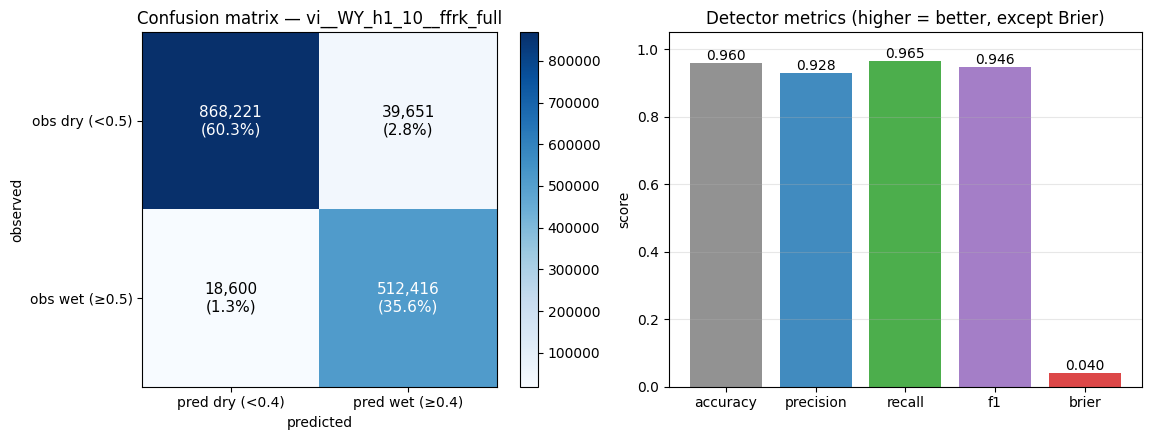

P(obs wet)  = 0.369   (sanity ~ 0.5-0.7 for central European climate)
P(pred wet) = 0.384   (if well below obs, model is conservative on wet)


In [14]:
tp, fp, tn, fn = metrics['tp'], metrics['fp'], metrics['tn'], metrics['fn']
cm = np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (1) confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred dry (<0.4)', 'pred wet (>=0.4)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['obs dry (<0.5)', 'obs wet (>=0.5)'])
ax.set_xlabel('predicted'); ax.set_ylabel('observed')
ax.set_title(f'Confusion matrix - {EXP_NAME}')
n_total = cm.sum()
for i in range(2):
    for j in range(2):
        v = cm[i, j]
        pct = 100 * v / n_total
        col = 'white' if v > cm.max()/2 else 'black'
        ax.text(j, i, f'{v:,}\n({pct:.1f}%)', ha='center', va='center', color=col, fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)

# (2) bar chart of P/R/F1/Brier/Accuracy
ax = axes[1]
keys = ['accuracy', 'precision', 'recall', 'f1', 'brier']
vals = [metrics[k] for k in keys]
colors = ['tab:gray', 'tab:blue', 'tab:green', 'tab:purple', 'tab:red']
bars = ax.bar(keys, vals, color=colors, alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('Detector metrics (higher = better, except Brier)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print(f'P(obs wet)  = {(tp+fn)/n_total:.3f}   (sanity ~ 0.5-0.7 for central European climate)')
print(f'P(pred wet) = {(tp+fp)/n_total:.3f}   (if well below obs, model is conservative on wet)')

## 13. Interval calibration — global vs wet-only

We build the 11-point reliability curve **twice**: on the full test and on
observed-wet only. Global over-coverage is a typical ZINB artefact (zeros
inflate coverage at low α). The wet-only curve shows the real conditional
calibration given rain.

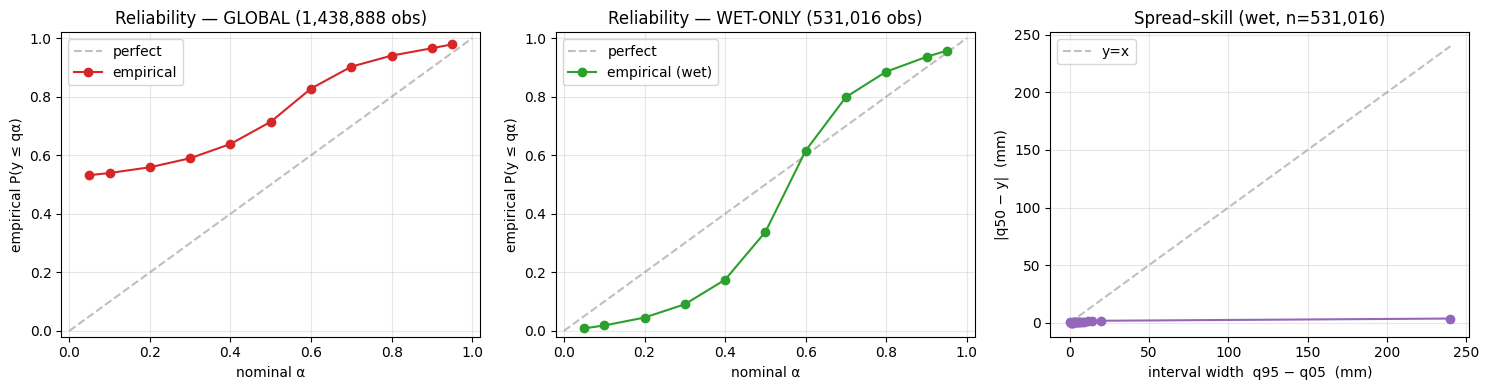

Wet-only reliability:
  α=0.05  emp=0.009  Δ=-0.041  down
  α=0.10  emp=0.018  Δ=-0.082  down
  α=0.20  emp=0.045  Δ=-0.155  down
  α=0.30  emp=0.091  Δ=-0.209  down
  α=0.40  emp=0.175  Δ=-0.225  down
  α=0.50  emp=0.338  Δ=-0.162  down
  α=0.60  emp=0.616  Δ=+0.016  ok
  α=0.70  emp=0.799  Δ=+0.099  up
  α=0.80  emp=0.886  Δ=+0.086  up
  α=0.90  emp=0.936  Δ=+0.036  up
  α=0.95  emp=0.957  Δ=+0.007  ok


In [15]:
y    = preds['observed_mm'].to_numpy()
mean = preds['mean_mm'    ].to_numpy()
q05  = preds['q05'].to_numpy()
q95  = preds['q95'].to_numpy()
wet  = y >= WET_THRESHOLD_MM if 'WET_THRESHOLD_MM' in globals() else (y >= 0.5)

Q_LABELS = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
Q_LEVELS = np.array([l / 100 for l in Q_LABELS])
q_cols = [f'q{l:02d}' for l in Q_LABELS]
Q = np.stack([preds[c].to_numpy() for c in q_cols], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) reliability - global
emp_global = np.array([(y <= Q[:, k]).mean() for k in range(len(Q_LABELS))])
ax = axes[0]
ax.plot([0,1],[0,1],'--', color='grey', alpha=0.5, label='perfect')
ax.plot(Q_LEVELS, emp_global, 'o-', ms=6, color='tab:red', label='empirical')
ax.set_xlabel('nominal α'); ax.set_ylabel('empirical P(y <= qα)')
ax.set_title(f'Reliability - GLOBAL ({len(y):,} obs)')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3); ax.legend()

# (2) reliability - wet-only
emp_wet = np.array([(y[wet] <= Q[wet, k]).mean() for k in range(len(Q_LABELS))])
ax = axes[1]
ax.plot([0,1],[0,1],'--', color='grey', alpha=0.5, label='perfect')
ax.plot(Q_LEVELS, emp_wet, 'o-', ms=6, color='tab:green', label='empirical (wet)')
ax.set_xlabel('nominal α'); ax.set_ylabel('empirical P(y <= qα)')
ax.set_title(f'Reliability - WET-ONLY ({wet.sum():,} obs)')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3); ax.legend()

# (3) spread-skill (wet-only)
q50 = preds['q50'].to_numpy()
width = (q95 - q05)[wet]
err   = np.abs(q50 - y)[wet]
ax = axes[2]
K = 20
edges = np.quantile(width, np.linspace(0, 1, K+1))
centers = 0.5 * (edges[:-1] + edges[1:])
ids = np.clip(np.digitize(width, edges[1:-1]), 0, K-1)
mean_err = np.array([err[ids == k].mean() if (ids == k).any() else np.nan
                     for k in range(K)])
ax.plot(centers, mean_err, 'o-', color='tab:purple')
lim = max(np.nanmax(centers), np.nanmax(mean_err))
ax.plot([0, lim], [0, lim], '--', color='grey', alpha=0.5, label='y=x')
ax.set_xlabel('interval width  q95 - q05  (mm)')
ax.set_ylabel('|q50 - y|  (mm)')
ax.set_title(f'Spread-skill (wet, n={wet.sum():,})')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('Wet-only reliability:')
for lvl, e in zip(Q_LEVELS, emp_wet):
    bias = e - lvl
    marker = '  ok' if abs(bias) < 0.02 else ('  up' if bias > 0 else '  down')
    print(f'  α={lvl:.2f}  emp={e:.3f}  Δ={bias:+.3f}{marker}')

## 14. Observed vs Predicted — two views

Left: **wet-only scatter** (the dry mass is just a cloud at zero); right:
**per-station MAE map** computed on wet points.

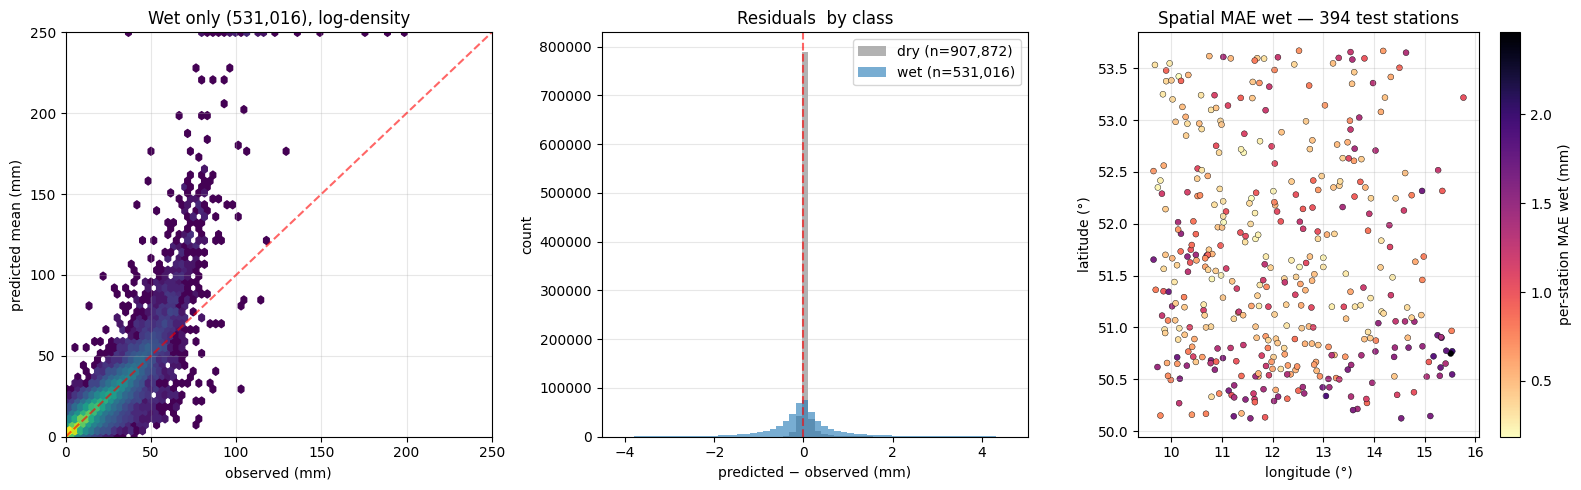

top-5 worst stations (wet MAE):
                   lat        lon       mae     n
station_id                                       
CZ_P2DVOR01  50.748172  15.514525  2.461554  1678
CZ_H1LBOU01  50.770000  15.545300  1.949618  1910
CZ_L3STRA01  50.338600  13.051700  1.892948  1276
PL_5101      50.900000  15.333333  1.848388  1727
CZ_U2JANI01  50.721400  15.176400  1.838110  1481


In [16]:
y    = preds['observed_mm'].to_numpy()
yhat = preds['mean_mm'    ].to_numpy()
wet  = y >= 0.5

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) scatter (wet-only)
ax = axes[0]
ax.hexbin(y[wet], yhat[wet], gridsize=60, mincnt=1, bins='log', cmap='viridis')
lim = max(y[wet].max(), yhat[wet].max())
ax.plot([0, lim], [0, lim], '--', color='red', alpha=0.6, lw=1.5)
ax.set_xlabel('observed (mm)'); ax.set_ylabel('predicted mean (mm)')
ax.set_title(f'Wet only ({wet.sum():,}), log-density')
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.grid(alpha=0.3)

# (2) histogram of residuals (split wet/dry)
ax = axes[1]
res_wet = yhat[wet] - y[wet]
res_dry = yhat[~wet] - y[~wet]
qs = np.quantile(yhat - y, [0.005, 0.995])
ax.hist(res_dry, bins=60, range=qs, color='tab:gray',  alpha=0.6, label=f'dry (n={(~wet).sum():,})')
ax.hist(res_wet, bins=60, range=qs, color='tab:blue',  alpha=0.6, label=f'wet (n={wet.sum():,})')
ax.axvline(0, color='red', ls='--', alpha=0.6)
ax.set_xlabel('predicted - observed (mm)'); ax.set_ylabel('count')
ax.set_title('Residuals  by class')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# (3) per-station MAE (wet-only) map
ax = axes[2]
df_wet = preds[wet].assign(abs_err=np.abs(yhat[wet] - y[wet]))
per_st = df_wet.groupby('station_id').agg(
    lat=('latitude','first'), lon=('longitude','first'),
    mae=('abs_err','mean'),   n=('abs_err','size'))
sc = ax.scatter(per_st['lon'], per_st['lat'], c=per_st['mae'],
                s=18, cmap='magma_r', edgecolor='black', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='per-station MAE wet (mm)')
ax.set_xlabel('longitude (deg)'); ax.set_ylabel('latitude (deg)')
ax.set_title(f'Spatial MAE wet - {len(per_st)} test stations')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('top-5 worst stations (wet MAE):')
print(per_st.sort_values('mae', ascending=False).head(5).to_string())

## 15. Time series for 4 example stations

Black dots: observed; red line: `mean_mm`; grey band: `[q05, q95]`. We pick
worst-MAE, median, best and one random station.

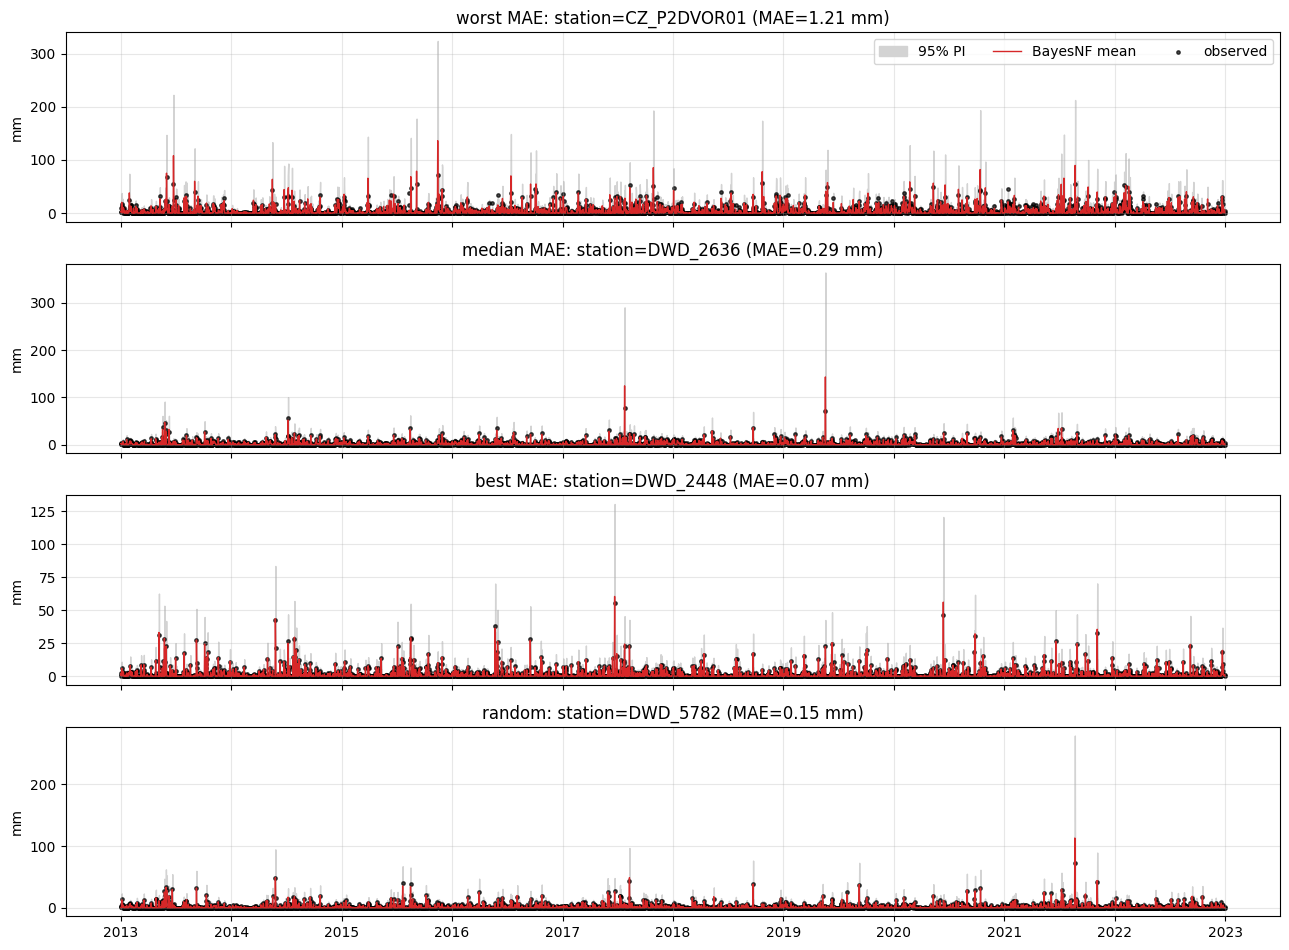

In [17]:
per_st = (preds.assign(abs_err=np.abs(preds['mean_mm'] - preds['observed_mm']))
                .groupby('station_id').agg(mae=('abs_err','mean')))
rng = np.random.default_rng(0)
picks = {
    'worst MAE' : per_st['mae'].idxmax(),
    'median MAE': per_st['mae'].sort_values().index[len(per_st)//2],
    'best MAE'  : per_st['mae'].idxmin(),
    'random'    : rng.choice(per_st.index),
}

fig, axes = plt.subplots(len(picks), 1,
                         figsize=(13, 2.4*len(picks)), sharex=True)
for ax, (label, sid) in zip(axes, picks.items()):
    s = preds[preds.station_id == sid].sort_values('datetime')
    ax.fill_between(s['datetime'], s['q05'], s['q95'],
                    color='lightgrey', label='95% PI')
    ax.plot(s['datetime'], s['mean_mm'], color='tab:red', lw=1.0,
            label='BayesNF mean')
    ax.scatter(s['datetime'], s['observed_mm'], color='black', s=6,
               label='observed', alpha=0.7)
    ax.set_ylabel('mm')
    ax.set_title(f'{label}: station={sid} (MAE={per_st.loc[sid,"mae"]:.2f} mm)')
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper right', ncol=3)
plt.tight_layout(); plt.show()


## 16. Semivariogram diagnostic — wet days only

Saad et al. 2024, Fig. 5. By eq. 14:
$2\gamma(h, \tau) = \mathrm{Var}\bigl[Y(s+h,\,t+\tau) - Y(s,\,t)\bigr]$.

We keep only days where **at least 10% of stations are wet** (`observed_mm ≥
0.5`) — on fully dry days γ ≈ 0 for obs and any non-zero for inferred makes the
ratio blow up. Wet days give a meaningful diagnostic.

wet days kept    : 2306 / 3652 (63.1%)
computing empirical (wet days) ...
computing inferred  (wet days) ...


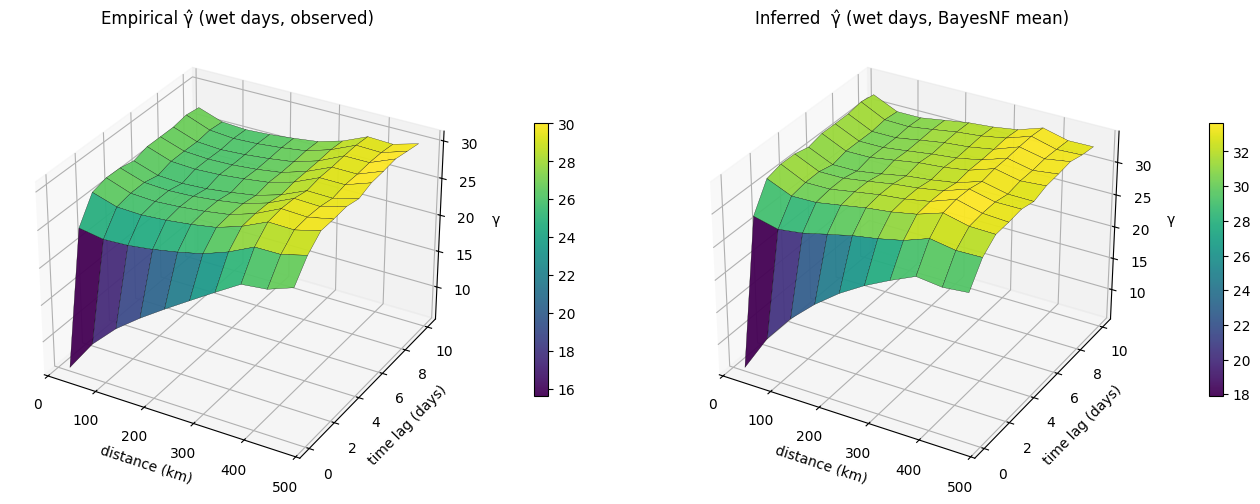

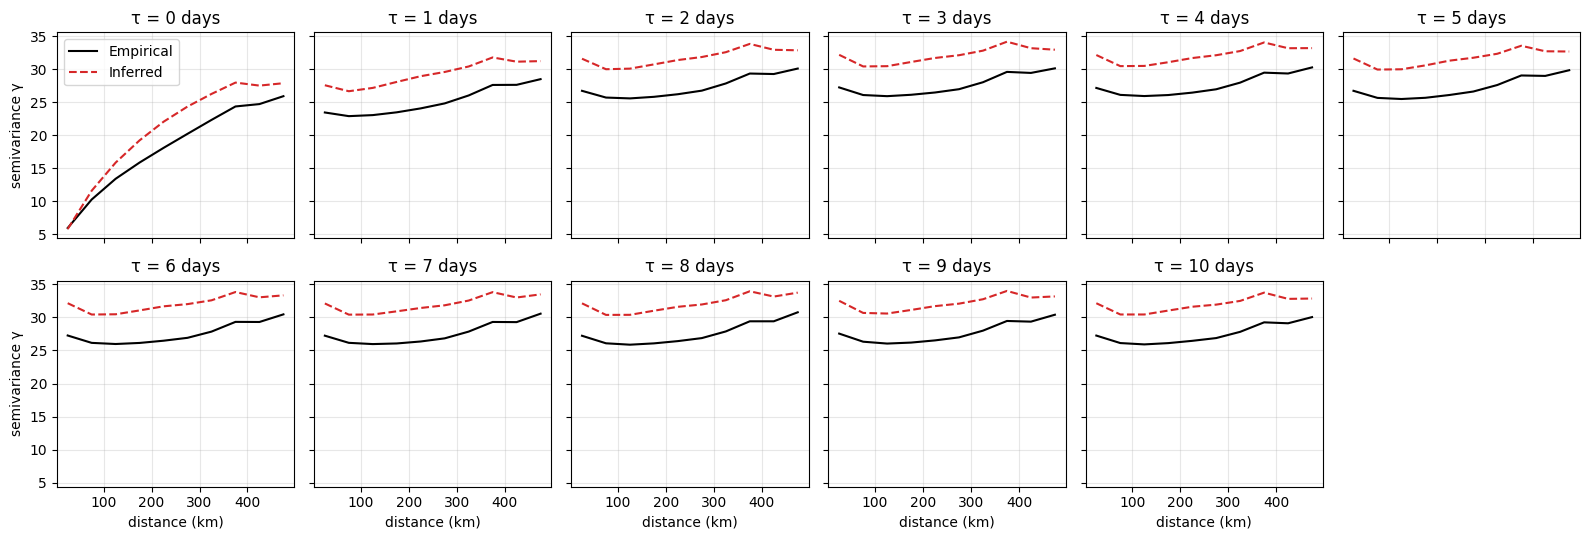

mean |γ_inf − γ_obs| / γ_obs over (h,τ)        = 0.163
  short lags τ ∈ {0,1,2}                       = 0.159
  long  lags τ ∈ {3..10}                       = 0.164


In [18]:
DIST_EDGES_KM = np.arange(0, 525, 50)
TIME_LAGS     = np.arange(0, 11)

stations = sorted(preds['station_id'].unique())
S = len(stations)

lat = np.array([coords.loc[s, 'latitude']  for s in stations])
lon = np.array([coords.loc[s, 'longitude'] for s in stations])
R = 6371.0
lat_r = np.radians(lat); lon_r = np.radians(lon)
dlat = lat_r[:, None] - lat_r[None, :]
dlon = lon_r[:, None] - lon_r[None, :]
a = np.sin(dlat/2)**2 + np.cos(lat_r)[:, None]*np.cos(lat_r)[None, :]*np.sin(dlon/2)**2
D_km = 2*R*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

iu, ju = np.triu_indices(S, k=1)
d_pair = D_km[iu, ju]
bin_id = np.clip(np.digitize(d_pair, DIST_EDGES_KM[1:-1]), 0, len(DIST_EDGES_KM)-2)
nb = len(DIST_EDGES_KM) - 1

obs_panel  = (preds.pivot_table('observed_mm', index='datetime', columns='station_id')
                   .reindex(columns=stations).sort_index())
pred_panel = (preds.pivot_table('mean_mm',     index='datetime', columns='station_id')
                   .reindex(columns=stations).sort_index())

# keep days where >=10% of stations had y >= 0.5 mm
day_wet_frac = (obs_panel >= 0.5).mean(axis=1)
wet_days = day_wet_frac >= 0.10
print(f'wet days kept    : {wet_days.sum()} / {len(wet_days)} '
      f'({100*wet_days.mean():.1f}%)')

OBS  = obs_panel [wet_days].to_numpy(dtype=np.float32)
PRED = pred_panel[wet_days].to_numpy(dtype=np.float32)

def _semivariogram(panel):
    out = np.full((len(TIME_LAGS), nb), np.nan, dtype=np.float64)
    for k, tau in enumerate(TIME_LAGS):
        A = panel if tau == 0 else panel[:-tau]
        B = panel if tau == 0 else panel[tau:]
        diff = A[:, iu] - B[:, ju]
        sq = (diff * diff).astype(np.float64)
        mask = np.isfinite(sq)
        if not mask.any():
            continue
        flat_sq = sq[mask]
        flat_bin = np.broadcast_to(bin_id[None, :], sq.shape)[mask]
        sums = np.bincount(flat_bin, weights=flat_sq, minlength=nb)
        cnts = np.bincount(flat_bin, minlength=nb).astype(np.float64)
        with np.errstate(invalid='ignore'):
            out[k] = np.where(cnts > 0, 0.5 * sums / np.maximum(cnts, 1), np.nan)
    return out

print('computing empirical (wet days) ...', flush=True)
gamma_obs = _semivariogram(OBS)
print('computing inferred  (wet days) ...', flush=True)
gamma_inf = _semivariogram(PRED)

H = 0.5*(DIST_EDGES_KM[:-1] + DIST_EDGES_KM[1:])
HH, TT = np.meshgrid(H, TIME_LAGS)
fig = plt.figure(figsize=(14, 5))
for sub, (G, title) in enumerate(
        [(gamma_obs, 'Empirical γ̂ (wet days, observed)'),
         (gamma_inf, 'Inferred  γ̂ (wet days, BayesNF mean)')], 1):
    ax = fig.add_subplot(1, 2, sub, projection='3d')
    surf = ax.plot_surface(HH, TT, G, cmap='viridis',
                           edgecolor='k', linewidth=0.2, alpha=0.95)
    ax.set_xlabel('distance (km)'); ax.set_ylabel('time lag (days)')
    ax.set_zlabel('γ'); ax.set_title(title)
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 6, figsize=(16, 5.5), sharex=True, sharey=True)
for k, tau in enumerate(TIME_LAGS):
    ax = axes.flat[k]
    ax.plot(H, gamma_obs[k], '-',  color='black',   lw=1.5, label='Empirical')
    ax.plot(H, gamma_inf[k], '--', color='tab:red', lw=1.5, label='Inferred')
    ax.set_title(f'τ = {tau} days')
    ax.grid(alpha=0.3)
    if k == 0: ax.legend()
    if k % 6 == 0: ax.set_ylabel('semivariance γ')
    if k // 6 == 1: ax.set_xlabel('distance (km)')
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

with np.errstate(divide='ignore', invalid='ignore'):
    rel = np.abs(gamma_inf - gamma_obs) / np.where(gamma_obs > 0, gamma_obs, np.nan)
print(f'mean |γ_inf - γ_obs| / γ_obs over (h,τ)        = {np.nanmean(rel):.3f}')
print(f'  short lags τ in {{0,1,2}}                     = {np.nanmean(rel[:3]):.3f}')
print(f'  long  lags τ in {{3..10}}                     = {np.nanmean(rel[3:]):.3f}')